In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------- USER INPUT --------
emory_file = "/hpc/home/yy450/link_dctrl_yy450/Sepy2.0/0_mimic_gen_flat_files/flatfiles-review/combine-labs/emory-labs-joined.csv"
mimic_file = "/hpc/home/yy450/link_dctrl_yy450/Sepy2.0/0_mimic_gen_flat_files/flatfiles-review/combine-labs/mimic-labs-joined.csv"

emory_grouping_file = "/hpc/home/yy450/link_dctrl_yy450/Sepy2.0/0_mimic_gen_flat_files/flatfiles-review/combine-labs/emory-labs-grouping-joined.csv"
mimic_grouping_file = "/hpc/home/yy450/link_dctrl_yy450/Sepy2.0/mimic_groupings/mimic_grouping_labs_new.csv"
# ----------------------------

# Load DataFrames
# df_emory = pd.read_csv(emory_file, sep='|')
df_emory = pd.read_csv(emory_file)
df_mimic = pd.read_csv(mimic_file)

df_emory_grouping = pd.read_csv(emory_grouping_file)
df_mimic_grouping = pd.read_csv(mimic_grouping_file)

print(f"✅ Loaded Emory: {df_emory.shape}, MIMIC: {df_mimic.shape}")
print(f"📋 Emory Columns: {list(df_emory.columns)}")
print(f"📋 MIMIC Columns: {list(df_mimic.columns)}")

# 🧪 Filter Emory by medication_id
# if "medication_id" not in df_emory.columns:
#     raise ValueError("'medication_id' column not found in Emory file.")

✅ Loaded Emory: (18983014, 15), MIMIC: (84605867, 13)
📋 Emory Columns: ['pat_id', 'csn', 'proc_cat_id', 'proc_cat_name', 'proc_code', 'proc_desc', 'component_id', 'component', 'loinc_code', 'collection_time', 'result_status', 'lab_result_time', 'lab_result', 'super_table_col_name', 'import']
📋 MIMIC Columns: ['csn', 'pat_id', 'component', 'component_id', 'lab_result', 'lab_result_unit', 'lab_result_time', 'collection_time', 'result_status', 'proc_cat_name', 'proc_desc', 'super_table_col_name', 'import']


In [18]:

# Emory analysis: list of medication IDs to filter by
filter_column = ['lipase']  # <-- Can add multiple ids e.g. [2196639, 2196640, 2196641]
emory_col = "lab_result"

# MIMIC analysis: directly analyze this column
mimic_col = "lab_result"

In [19]:
df_emory_grouping_filtered = df_emory_grouping[
    (df_emory_grouping["super_table_col_name"].isin(filter_column)) &
    (df_emory_grouping["import"] == "Yes")
]
df_mimic_grouping_filtered = df_mimic_grouping[
    (df_mimic_grouping["super_table_col_name"].isin(filter_column)) &
    (df_mimic_grouping["import"] == "Yes")
]

print(f"🔍 Emory: super_table_col_name {filter_column} comes from the following [component, component_id, proc_cat_name, proc_desc]: \n {df_emory_grouping_filtered[['component', 'component_id', 'proc_cat_name', 'proc_desc']]}")
print(f"🔍 MIMIC: super_table_col_name {filter_column} comes from the following [component, component_id, proc_cat_name, proc_desc]: \n {df_mimic_grouping_filtered[['component', 'component_id', 'proc_cat_name', 'proc_desc']]}")

🔍 Emory: super_table_col_name ['lipase'] comes from the following [component, component_id, proc_cat_name, proc_desc]: 
     component  component_id proc_cat_name proc_desc
112    Lipase       1513547         Blood    Lipase
🔍 MIMIC: super_table_col_name ['lipase'] comes from the following [component, component_id, proc_cat_name, proc_desc]: 
               component  component_id     proc_cat_name  proc_desc
42      Lipase, Ascites         50844           Ascites  Chemistry
153              Lipase         50956             Blood  Chemistry
224  Lipase, Body Fluid         51036  Other Body Fluid  Chemistry
243     Lipase, Pleural         51055           Pleural  Chemistry


In [20]:
df_emory_filtered = df_emory[
    (df_emory["super_table_col_name"].isin(filter_column)) &
    (df_emory["import"] == "Yes")
]
print(f"🔍 Emory rows after filtering by super_table_col_name {filter_column}: {df_emory_filtered.shape[0]} rows")

df_mimic_filtered = df_mimic[
    (df_mimic["super_table_col_name"].isin(filter_column)) &
    (df_mimic["import"] == "Yes")
]
print(f"🔍 MIMIC rows after filtering by super_table_col_name {filter_column}: {df_mimic_filtered.shape[0]} rows")

# Check column existence
if emory_col not in df_emory.columns:
    raise ValueError(f"'{emory_col}' not found in Emory file.")
if mimic_col not in df_mimic.columns:
    raise ValueError(f"'{mimic_col}' not found in MIMIC file.")


# e_col = df_emory_filtered[emory_col]
# m_col = df_mimic_filtered[mimic_col]

# Extract target columns
# Transform to numeric, coercing errors to NaN
e_col = pd.to_numeric(df_emory_filtered[emory_col], errors='coerce')
m_col = pd.to_numeric(df_mimic_filtered[mimic_col], errors='coerce')

🔍 Emory rows after filtering by super_table_col_name ['lipase']: 29308 rows
🔍 MIMIC rows after filtering by super_table_col_name ['lipase']: 93710 rows


In [21]:

# -- 1. Null Count --
print("\n🧼 Null Counts:")
print(f"Emory - {emory_col}: {e_col.isnull().sum()} nulls out of {len(e_col)}")
print(f"MIMIC - {mimic_col}: {m_col.isnull().sum()} nulls out of {len(m_col)}")



🧼 Null Counts:
Emory - lab_result: 483 nulls out of 29308
MIMIC - lab_result: 76 nulls out of 93710


In [22]:
pd.options.display.float_format = '{:.4f}'.format

# -- 2. Summary Stats --
print("\n📊 Summary Statistics:")
print("\nEmory:")
display(e_col.describe(include='all'))
print("\nMIMIC:")
display(m_col.describe(include='all'))



📊 Summary Statistics:

Emory:


count   28825.0000
mean       62.7624
std       187.9155
min         3.0000
25%        15.0000
50%        25.0000
75%        45.0000
max      7861.0000
Name: lab_result, dtype: float64


MIMIC:


count    93634.0000
mean       153.3392
std       2018.4586
min          0.0000
25%         21.0000
50%         37.0000
75%         81.0000
max     322000.0000
Name: lab_result, dtype: float64

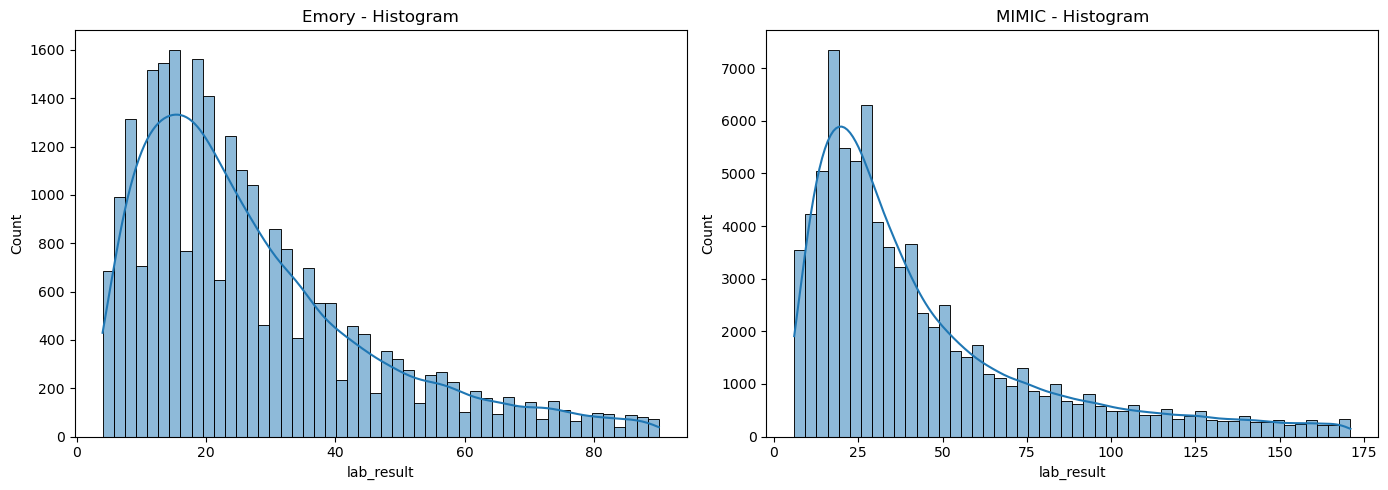

In [23]:
def plot_column_dist(col, source_name, ax, value_range=None):
    if pd.api.types.is_numeric_dtype(col):
        col_to_plot = col.dropna()
        if value_range:
            col_to_plot = col_to_plot[(col_to_plot >= value_range[0]) & (col_to_plot <= value_range[1])]
        sns.histplot(col_to_plot, kde=True, bins=50, ax=ax)
        ax.set_title(f"{source_name} - Histogram")
        ax.set_xlabel(col.name)
    else:
        col.value_counts().plot(kind='bar', ax=ax)
        ax.set_title(f"{source_name} - Bar Chart")
        ax.set_ylabel("Count")
        ax.set_xlabel(col.name)

def smart_value_range(col):
    desc = col.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
    q1, q3 = desc['25%'], desc['75%']
    iqr = q3 - q1
    lower_iqr, upper_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    lower_q, upper_q = desc['1%'], desc['99%']
    # 选取相对紧的范围
    lower = max(lower_iqr, lower_q)
    upper = min(upper_iqr, upper_q)
    return lower, upper


# value_range = (0, 10)  # <- You can adjust this range based on expected values
e_value_range = smart_value_range(e_col)
m_value_range = smart_value_range(m_col)

# value_range = None  # <- No range filtering

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_column_dist(e_col, "Emory", axes[0], value_range=e_value_range)
plot_column_dist(m_col, "MIMIC", axes[1], value_range=m_value_range)
plt.tight_layout()
plt.show()


In [24]:

# -- 3.5 Unique Values (for non-numeric) --
if not pd.api.types.is_numeric_dtype(e_col):
    print(f"\n📋 Emory unique values in '{emory_col}':")
    print(e_col.value_counts(dropna=False))

if not pd.api.types.is_numeric_dtype(m_col):
    print(f"\n📋 MIMIC unique values in '{mimic_col}':")
    print(m_col.value_counts(dropna=False))


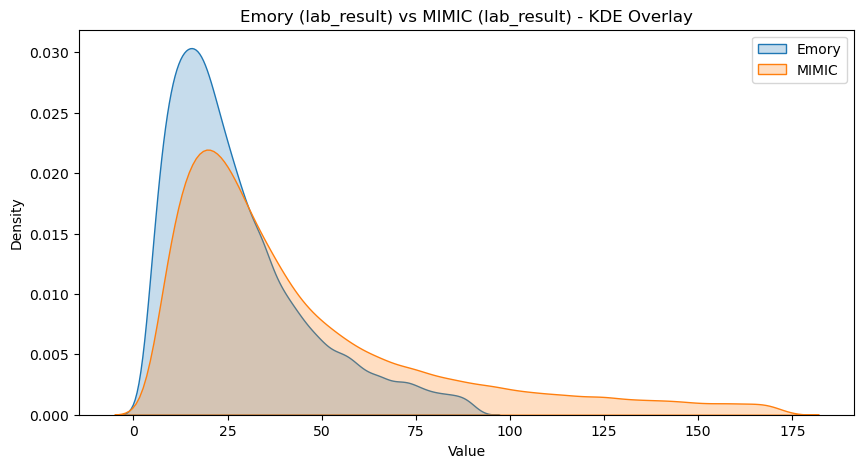

In [25]:
if pd.api.types.is_numeric_dtype(e_col) and pd.api.types.is_numeric_dtype(m_col):
    plt.figure(figsize=(10, 5))

    e_kde = e_col.dropna()
    m_kde = m_col.dropna()

    if e_value_range or m_value_range:
        e_kde = e_kde[(e_kde >= e_value_range[0]) & (e_kde <= e_value_range[1])]
        m_kde = m_kde[(m_kde >= m_value_range[0]) & (m_kde <= m_value_range[1])]

    sns.kdeplot(e_kde, label='Emory', fill=True)
    sns.kdeplot(m_kde, label='MIMIC', fill=True)
    plt.title(f"Emory ({emory_col}) vs MIMIC ({mimic_col}) - KDE Overlay")
    plt.xlabel("Value")
    plt.legend()
    plt.show()
else:
    print("\n⚠️ Skipping side-by-side KDE plot: one or both columns are not numeric.")
